
# Onion Disease Classification — Fixed 5-Model H5 Stacking Ensemble

This version fixes the Kaggle path problem.

### What is fixed
- It **does not assume a model directory**.
- It scans **all of `/kaggle/input`** for `.h5` / `.weights.h5` files.
- It automatically matches:
  - ConvNeXtTiny
  - EfficientNetV2B0
  - DenseNet121
  - ResNet50V2
  - Xception
- It automatically finds the onion dataset by searching for a valid:
  - `train / valid / test`
  - `train / val / test`
  - `train / validation / test`
  structure containing the expected four classes.
- It supports both:
  - complete legacy `.h5` Keras models
  - weights-only `.weights.h5` files

Then it generates validation/test predictions, trains the stacking meta-classifier, and reports all requested metrics.


In [17]:

# ============================================================
# 1. Imports, versions, reproducibility, and GPU check
# ============================================================

import os
import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__ if hasattr(keras, "__version__") else "tf.keras")

gpus = tf.config.list_physical_devices("GPU")
print("GPU(s):", gpus)

if not gpus:
    print("\nWARNING: No GPU detected. The notebook will still work, but base-model inference will be slower.")
else:
    print("\nGPU is available.")


TensorFlow: 2.20.0
Keras: 3.13.2
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

GPU is available.


In [18]:

# ============================================================
# 2. Configuration
# ============================================================

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["molded", "normal", "rotten", "sprouted"]
NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE_224 = 224
IMG_SIZE_299 = 299

PRED_BATCH_SIZE = 16

META_VALID_FRACTION = 0.20
META_BATCH_SIZE = 32
META_MAX_EPOCHS = 500
META_EARLY_STOP_PATIENCE = 12

MODEL_SPECS = {
    "ConvNeXtTiny": {
        "keywords": ["convnext"],
        "image_size": IMG_SIZE_224,
    },
    "EfficientNetV2B0": {
        "keywords": ["effnet", "efficientnet"],
        "image_size": IMG_SIZE_224,
    },
    "DenseNet121": {
        "keywords": ["densenet"],
        "image_size": IMG_SIZE_224,
    },
    "ResNet50V2": {
        "keywords": ["resnet"],
        "image_size": IMG_SIZE_224,
    },
    "Xception": {
        "keywords": ["xception"],
        "image_size": IMG_SIZE_299,
    },
}

print("Kaggle input root:", KAGGLE_INPUT_ROOT)
print("Expected class order:", CLASS_NAMES)


Kaggle input root: /kaggle/input
Expected class order: ['molded', 'normal', 'rotten', 'sprouted']


In [19]:

# ============================================================
# 3. Automatically locate the onion dataset
# ============================================================

def class_dirs_match(split_dir: Path):
    if not split_dir.is_dir():
        return False

    found = sorted([
        p.name.lower()
        for p in split_dir.iterdir()
        if p.is_dir()
    ])

    expected = sorted([c.lower() for c in CLASS_NAMES])

    return found == expected


def find_dataset_root(base_dir: Path):
    if not base_dir.exists():
        raise FileNotFoundError(
            f"{base_dir} does not exist."
        )

    split_name_sets = [
        ("train", "valid", "test"),
        ("train", "val", "test"),
        ("train", "validation", "test"),
    ]

    candidates = [base_dir]
    candidates.extend([
        p for p in base_dir.rglob("*")
        if p.is_dir()
    ])

    matches = []

    for p in candidates:
        for train_name, val_name, test_name in split_name_sets:
            train_dir = p / train_name
            val_dir = p / val_name
            test_dir = p / test_name

            if (
                train_dir.is_dir()
                and val_dir.is_dir()
                and test_dir.is_dir()
                and class_dirs_match(train_dir)
                and class_dirs_match(val_dir)
                and class_dirs_match(test_dir)
            ):
                matches.append(
                    (p, train_name, val_name, test_name)
                )

    if not matches:
        raise FileNotFoundError(
            "Could not automatically find the onion dataset under "
            "/kaggle/input.\n\n"
            "Make sure the onion dataset is added to the Kaggle notebook "
            "and contains train/valid/test (or train/val/test) folders "
            "with the classes molded, normal, rotten, sprouted."
        )

    # Prefer the shallowest path because it is usually the intended dataset root.
    matches = sorted(
        matches,
        key=lambda x: len(x[0].parts)
    )

    return matches[0]


DATA_ROOT, TRAIN_NAME, VAL_NAME, TEST_NAME = find_dataset_root(
    KAGGLE_INPUT_ROOT
)

TRAIN_DIR = DATA_ROOT / TRAIN_NAME
VAL_DIR = DATA_ROOT / VAL_NAME
TEST_DIR = DATA_ROOT / TEST_NAME

print("Detected dataset root :", DATA_ROOT)
print("Train directory       :", TRAIN_DIR)
print("Validation directory  :", VAL_DIR)
print("Test directory        :", TEST_DIR)


Detected dataset root : /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined
Train directory       : /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/train
Validation directory  : /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/valid
Test directory        : /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined/test


In [20]:

# ============================================================
# 4. Verify classes and collect validation/test image paths
# ============================================================

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def available_class_dirs(split_dir: Path):
    return sorted([p.name for p in split_dir.iterdir() if p.is_dir()])

def verify_split_classes(split_dir: Path, split_name: str):
    found = available_class_dirs(split_dir)
    expected = sorted(CLASS_NAMES)

    print(f"{split_name} classes:", found)

    if found != expected:
        raise ValueError(
            f"{split_name} class folders do not match the classes used to train "
            f"the five models.\nExpected: {expected}\nFound: {found}"
        )

verify_split_classes(VAL_DIR, "Validation")
verify_split_classes(TEST_DIR, "Test")


def collect_paths_and_labels(split_dir: Path):
    paths = []
    labels = []

    for class_index, class_name in enumerate(CLASS_NAMES):
        class_dir = split_dir / class_name

        class_files = sorted(
            [
                p for p in class_dir.rglob("*")
                if p.is_file() and p.suffix.lower() in IMAGE_EXTS
            ],
            key=lambda p: str(p).lower(),
        )

        if not class_files:
            raise ValueError(f"No images found in {class_dir}")

        paths.extend([str(p) for p in class_files])
        labels.extend([class_index] * len(class_files))

    return np.asarray(paths), np.asarray(labels, dtype=np.int32)


val_paths, y_val = collect_paths_and_labels(VAL_DIR)
test_paths, y_test = collect_paths_and_labels(TEST_DIR)

print("\nValidation images:", len(val_paths))
print("Test images      :", len(test_paths))

print("\nValidation distribution:")
display(
    pd.Series(y_val)
    .value_counts()
    .sort_index()
    .rename(index=dict(enumerate(CLASS_NAMES)))
    .rename("count")
    .to_frame()
)

print("Test distribution:")
display(
    pd.Series(y_test)
    .value_counts()
    .sort_index()
    .rename(index=dict(enumerate(CLASS_NAMES)))
    .rename("count")
    .to_frame()
)


Validation classes: ['molded', 'normal', 'rotten', 'sprouted']
Test classes: ['molded', 'normal', 'rotten', 'sprouted']

Validation images: 506
Test images      : 253

Validation distribution:


,count
molded,75
normal,202
rotten,43
sprouted,186


Test distribution:


,count
molded,38
normal,101
rotten,21
sprouted,93


In [21]:

# ============================================================
# 5. Automatically find the five H5 model files
# ============================================================

all_h5 = sorted(KAGGLE_INPUT_ROOT.rglob("*.h5"))

print("H5 files found under /kaggle/input:")
for p in all_h5:
    print(" ", p)

if not all_h5:
    raise FileNotFoundError(
        "No .h5 files were found anywhere under /kaggle/input.\n\n"
        "Add your Kaggle model dataset containing the five .h5 files."
    )


def resolve_h5_file(all_h5_files, keywords):
    candidates = []

    for p in all_h5_files:
        name = p.name.lower()

        if any(k.lower() in name for k in keywords):
            candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            f"No H5 file found for keywords {keywords}.\n\n"
            "Available H5 files:\n"
            + "\n".join(str(p) for p in all_h5_files)
        )

    def score(path):
        name = path.name.lower()

        return (
            30 * int("best" in name)
            + 20 * int("macro" in name)
            + 10 * int("weight" in name)
            + 5 * int("model" in name)
            + 1 * int("final" not in name)
        )

    return sorted(
        candidates,
        key=score,
        reverse=True
    )[0]


resolved_model_paths = {}

for model_name, spec in MODEL_SPECS.items():
    model_path = resolve_h5_file(
        all_h5,
        spec["keywords"],
    )

    resolved_model_paths[model_name] = model_path

    print(
        f"{model_name:18s} -> {model_path}"
    )


print("\nAll five model files located successfully.")


H5 files found under /kaggle/input:
  /kaggle/input/datasets/yashraneja/models-onion/Model Files/convnexttiny_model.weights.h5
  /kaggle/input/datasets/yashraneja/models-onion/Model Files/effnetv2b0model.weights.h5
  /kaggle/input/datasets/yashraneja/models-onion/Model Files/onion_densenet121_best_macro_f1.weights.h5
  /kaggle/input/datasets/yashraneja/models-onion/Model Files/resnet_model.weights.h5
  /kaggle/input/datasets/yashraneja/models-onion/Model Files/xception_model.weights.h5
ConvNeXtTiny       -> /kaggle/input/datasets/yashraneja/models-onion/Model Files/convnexttiny_model.weights.h5
EfficientNetV2B0   -> /kaggle/input/datasets/yashraneja/models-onion/Model Files/effnetv2b0model.weights.h5
DenseNet121        -> /kaggle/input/datasets/yashraneja/models-onion/Model Files/onion_densenet121_best_macro_f1.weights.h5
ResNet50V2         -> /kaggle/input/datasets/yashraneja/models-onion/Model Files/resnet_model.weights.h5
Xception           -> /kaggle/input/datasets/yashraneja/model

In [22]:

# ============================================================
# 5A. Final path check before loading models
# ============================================================

print("Dataset:")
print(" ", DATA_ROOT)

print("\nModels:")
for name, path in resolved_model_paths.items():
    print(f" {name:18s}: {path}")

missing = [
    str(path)
    for path in resolved_model_paths.values()
    if not Path(path).exists()
]

if missing:
    raise FileNotFoundError(
        "Some resolved model paths do not exist:\n"
        + "\n".join(missing)
    )

print("\nPath check passed.")


Dataset:
  /kaggle/input/datasets/yashraneja2/onion-dataset-combined/Roboflow dataset combined

Models:
 ConvNeXtTiny      : /kaggle/input/datasets/yashraneja/models-onion/Model Files/convnexttiny_model.weights.h5
 EfficientNetV2B0  : /kaggle/input/datasets/yashraneja/models-onion/Model Files/effnetv2b0model.weights.h5
 DenseNet121       : /kaggle/input/datasets/yashraneja/models-onion/Model Files/onion_densenet121_best_macro_f1.weights.h5
 ResNet50V2        : /kaggle/input/datasets/yashraneja/models-onion/Model Files/resnet_model.weights.h5
 Xception          : /kaggle/input/datasets/yashraneja/models-onion/Model Files/xception_model.weights.h5

Path check passed.


In [23]:

# ============================================================
# 6. Reconstruct the exact original architectures for weights-only H5
# ============================================================

def make_augmentation():
    """
    Same augmentation block used in the original five training notebooks.
    It is inactive during model.predict(), but is kept here so the reconstructed
    architecture matches the original model topology as closely as possible.
    """
    return keras.Sequential(
        [
            layers.RandomFlip(
                "horizontal_and_vertical",
                seed=SEED,
            ),
            layers.RandomRotation(
                0.08,
                fill_mode="reflect",
                seed=SEED,
            ),
            layers.RandomZoom(
                height_factor=(-0.12, 0.12),
                width_factor=(-0.12, 0.12),
                fill_mode="reflect",
                seed=SEED,
            ),
            layers.RandomTranslation(
                height_factor=0.08,
                width_factor=0.08,
                fill_mode="reflect",
                seed=SEED,
            ),
            layers.RandomContrast(
                0.12,
                seed=SEED,
            ),
        ],
        name="augmentation",
    )


def build_convnexttiny():
    img_size = 224
    augmentation = make_augmentation()

    base_model = keras.applications.ConvNeXtTiny(
        include_top=False,
        weights=None,
        input_shape=(img_size, img_size, 3),
        pooling="avg",
        include_preprocessing=True,
    )

    inputs = keras.Input(
        shape=(img_size, img_size, 3),
        name="image",
    )

    x = augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dropout(0.40, name="head_dropout_1")(x)
    x = layers.Dense(
        256,
        activation="gelu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="head_dense",
    )(x)
    x = layers.Dropout(0.25, name="head_dropout_2")(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="predictions",
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="onion_convnexttiny",
    )


def build_effnetv2b0():
    img_size = 224
    augmentation = make_augmentation()

    base_model = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights=None,
        input_shape=(img_size, img_size, 3),
        pooling="avg",
        include_preprocessing=True,
    )

    inputs = keras.Input(
        shape=(img_size, img_size, 3),
        name="image",
    )

    x = augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dropout(0.35, name="head_dropout_1")(x)
    x = layers.Dense(
        256,
        activation="swish",
        kernel_regularizer=regularizers.l2(1e-4),
        name="head_dense",
    )(x)
    x = layers.Dropout(0.25, name="head_dropout_2")(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="predictions",
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="onion_effnetv2b0",
    )


def build_densenet121():
    img_size = 224
    augmentation = make_augmentation()

    base_model = keras.applications.DenseNet121(
        include_top=False,
        weights=None,
        input_shape=(img_size, img_size, 3),
        pooling="avg",
    )

    inputs = keras.Input(
        shape=(img_size, img_size, 3),
        name="image",
    )

    x = augmentation(inputs)
    x = keras.applications.densenet.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dropout(0.35, name="head_dropout_1")(x)
    x = layers.Dense(
        256,
        activation="swish",
        kernel_regularizer=regularizers.l2(1e-4),
        name="head_dense",
    )(x)
    x = layers.Dropout(0.20, name="head_dropout_2")(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="predictions",
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="onion_densenet121",
    )


def build_resnet50v2():
    img_size = 224
    augmentation = make_augmentation()

    base_model = keras.applications.ResNet50V2(
        include_top=False,
        weights=None,
        input_shape=(img_size, img_size, 3),
        pooling="avg",
    )

    inputs = keras.Input(
        shape=(img_size, img_size, 3),
        name="image",
    )

    x = augmentation(inputs)
    x = layers.Rescaling(
        1.0 / 127.5,
        offset=-1.0,
        name="model_preprocessing",
    )(x)
    x = base_model(x, training=False)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dropout(0.35, name="head_dropout_1")(x)
    x = layers.Dense(
        256,
        activation="swish",
        kernel_regularizer=regularizers.l2(1e-4),
        name="head_dense",
    )(x)
    x = layers.Dropout(0.20, name="head_dropout_2")(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="predictions",
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="onion_resnet50v2",
    )


def build_xception():
    img_size = 299
    augmentation = make_augmentation()

    base_model = keras.applications.Xception(
        include_top=False,
        weights=None,
        input_shape=(img_size, img_size, 3),
        pooling="avg",
    )

    inputs = keras.Input(
        shape=(img_size, img_size, 3),
        name="image",
    )

    x = augmentation(inputs)
    x = layers.Rescaling(
        1.0 / 127.5,
        offset=-1.0,
        name="model_preprocessing",
    )(x)
    x = base_model(x, training=False)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dropout(0.40, name="head_dropout_1")(x)
    x = layers.Dense(
        256,
        activation="swish",
        kernel_regularizer=regularizers.l2(1e-4),
        name="head_dense",
    )(x)
    x = layers.Dropout(0.25, name="head_dropout_2")(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="predictions",
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name="onion_xception",
    )


BUILDERS = {
    "ConvNeXtTiny": build_convnexttiny,
    "EfficientNetV2B0": build_effnetv2b0,
    "DenseNet121": build_densenet121,
    "ResNet50V2": build_resnet50v2,
    "Xception": build_xception,
}

print("Architecture builders ready.")


Architecture builders ready.


In [24]:

# ============================================================
# 7. TensorFlow image-input pipeline
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

def decode_and_resize(path, image_size):
    image_bytes = tf.io.read_file(path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        [image_size, image_size],
        method="bilinear",
    )

    return image


def make_prediction_dataset(paths, image_size, batch_size=PRED_BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(paths)

    ds = ds.map(
        lambda p: decode_and_resize(p, image_size),
        num_parallel_calls=AUTOTUNE,
        deterministic=True,
    )

    ds = ds.batch(batch_size, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)

    return ds


val_ds_224 = make_prediction_dataset(val_paths, IMG_SIZE_224)
test_ds_224 = make_prediction_dataset(test_paths, IMG_SIZE_224)

val_ds_299 = make_prediction_dataset(val_paths, IMG_SIZE_299)
test_ds_299 = make_prediction_dataset(test_paths, IMG_SIZE_299)

print("224×224 validation batches:", tf.data.experimental.cardinality(val_ds_224).numpy())
print("299×299 validation batches:", tf.data.experimental.cardinality(val_ds_299).numpy())


224×224 validation batches: 32
299×299 validation batches: 32


In [25]:

# ============================================================
# 8. Load each H5 file and generate validation/test predictions
# ============================================================
#
# Robust loading strategy:
#   1. Try keras.models.load_model(...) in case the .h5 contains
#      the complete legacy Keras model.
#   2. If that fails, reconstruct the exact architecture and call
#      model.load_weights(...).
#
# Models are processed one at a time to reduce GPU-memory use.
# ============================================================

val_probabilities = {}
test_probabilities = {}
h5_load_modes = {}

def validate_loaded_model(model, model_name, expected_image_size):
    input_shape = model.input_shape
    output_shape = model.output_shape

    print("  input shape :", input_shape)
    print("  output shape:", output_shape)

    if isinstance(input_shape, list):
        raise ValueError(
            f"{model_name} unexpectedly has multiple inputs: {input_shape}"
        )

    if input_shape[-1] != 3:
        raise ValueError(
            f"{model_name} does not appear to accept RGB images."
        )

    if input_shape[1] is not None and int(input_shape[1]) != expected_image_size:
        raise ValueError(
            f"{model_name} expects input height {input_shape[1]}, "
            f"but this notebook expects {expected_image_size}."
        )

    if output_shape[-1] != NUM_CLASSES:
        raise ValueError(
            f"{model_name} outputs {output_shape[-1]} classes, "
            f"but this notebook expects {NUM_CLASSES}."
        )


def load_h5_for_inference(model_name, h5_path):
    """
    Returns:
        model, load_mode

    load_mode is either:
        'full_h5_model'
        'reconstructed_plus_load_weights'
    """
    try:
        model = keras.models.load_model(
            h5_path,
            compile=False,
        )

        print("Loaded directly as a complete H5 Keras model.")
        return model, "full_h5_model"

    except Exception as direct_error:
        print("Direct load_model() did not work.")
        print("Treating this as a weights-only H5 file.")
        print("Direct-load message:", str(direct_error).split("\n")[0])

    builder = BUILDERS[model_name]
    model = builder()

    try:
        status = model.load_weights(h5_path)
        print("Weights loaded successfully into reconstructed architecture.")
        return model, "reconstructed_plus_load_weights"

    except Exception as weight_error:
        raise RuntimeError(
            f"\nCould not load {h5_path.name} for {model_name}.\n"
            "The most likely reason is that this H5 file was created from "
            "a different architecture/head than the original notebook.\n\n"
            f"load_weights error:\n{weight_error}"
        ) from weight_error


for model_name, spec in MODEL_SPECS.items():

    print("\n" + "=" * 78)
    print(f"{model_name}")
    print("=" * 78)

    keras.backend.clear_session()
    gc.collect()

    h5_path = resolved_model_paths[model_name]
    print("H5 file:", h5_path)

    model, load_mode = load_h5_for_inference(
        model_name,
        h5_path,
    )

    model.trainable = False
    h5_load_modes[model_name] = load_mode

    expected_size = spec["image_size"]
    validate_loaded_model(
        model,
        model_name,
        expected_size,
    )

    if expected_size == IMG_SIZE_224:
        val_ds = val_ds_224
        test_ds = test_ds_224
    elif expected_size == IMG_SIZE_299:
        val_ds = val_ds_299
        test_ds = test_ds_299
    else:
        raise ValueError(
            f"Unsupported image size: {expected_size}"
        )

    print("\nValidation prediction:")
    val_prob = model.predict(
        val_ds,
        verbose=1,
    )

    print("\nTest prediction:")
    test_prob = model.predict(
        test_ds,
        verbose=1,
    )

    if val_prob.shape != (len(val_paths), NUM_CLASSES):
        raise ValueError(
            f"{model_name} validation output has unexpected shape "
            f"{val_prob.shape}"
        )

    if test_prob.shape != (len(test_paths), NUM_CLASSES):
        raise ValueError(
            f"{model_name} test output has unexpected shape "
            f"{test_prob.shape}"
        )

    val_sum_error = np.max(
        np.abs(val_prob.sum(axis=1) - 1.0)
    )
    test_sum_error = np.max(
        np.abs(test_prob.sum(axis=1) - 1.0)
    )

    print(
        f"Max validation probability-sum error: "
        f"{val_sum_error:.6f}"
    )
    print(
        f"Max test probability-sum error      : "
        f"{test_sum_error:.6f}"
    )

    val_probabilities[model_name] = (
        val_prob.astype(np.float32)
    )
    test_probabilities[model_name] = (
        test_prob.astype(np.float32)
    )

    del model
    keras.backend.clear_session()
    gc.collect()


print("\nFinished generating predictions.")

print("\nH5 loading modes:")
for name, mode in h5_load_modes.items():
    print(f"{name:18s}: {mode}")



ConvNeXtTiny
H5 file: /kaggle/input/datasets/yashraneja/models-onion/Model Files/convnexttiny_model.weights.h5
Direct load_model() did not work.
Treating this as a weights-only H5 file.
Direct-load message: No model config found in the file at /kaggle/input/datasets/yashraneja/models-onion/Model Files/convnexttiny_model.weights.h5.
Weights loaded successfully into reconstructed architecture.
  input shape : (None, 224, 224, 3)
  output shape: (None, 4)

Validation prediction:
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 252ms/step

Test prediction:
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 288ms/step
Max validation probability-sum error: 0.000000
Max test probability-sum error      : 0.000000

EfficientNetV2B0
H5 file: /kaggle/input/datasets/yashraneja/models-onion/Model Files/effnetv2b0model.weights.h5
Direct load_model() did not work.
Treating this as a weights-only H5 file.
Direct-load message: No model config found in the file at /kaggle/input/datasets/yashraneja/models-onion/Model Files/effnetv2b0model.we

In [26]:

# ============================================================
# 8. Save raw base-model predictions
# ============================================================

np.savez_compressed(
    OUTPUT_DIR / "onion_base_model_predictions.npz",
    y_val=y_val,
    y_test=y_test,
    val_paths=val_paths,
    test_paths=test_paths,
    **{
        f"val_{name}": probs
        for name, probs in val_probabilities.items()
    },
    **{
        f"test_{name}": probs
        for name, probs in test_probabilities.items()
    },
)

print("Saved:", OUTPUT_DIR / "onion_base_model_predictions.npz")


Saved: /kaggle/working/onion_base_model_predictions.npz


In [27]:

# ============================================================
# 9. Individual base-model test metrics
# ============================================================

def summary_metrics(y_true, probabilities):
    y_pred = np.argmax(probabilities, axis=1)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true, y_pred,
            labels=np.arange(NUM_CLASSES),
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true, y_pred,
            labels=np.arange(NUM_CLASSES),
            average="weighted",
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


base_rows = []

for model_name, probs in test_probabilities.items():
    row = {"model": model_name}
    row.update(summary_metrics(y_test, probs))
    base_rows.append(row)

base_test_summary = pd.DataFrame(base_rows).sort_values(
    "macro_f1", ascending=False
).reset_index(drop=True)

print("Individual model performance on the untouched test set:")
display(base_test_summary)

base_test_summary.to_csv(
    OUTPUT_DIR / "base_model_test_summary.csv",
    index=False,
)


Individual model performance on the untouched test set:


,model,accuracy,macro_f1,weighted_f1,balanced_accuracy
0,DenseNet121,0.988142,0.987774,0.988174,0.992148
1,ConvNeXtTiny,0.992095,0.986041,0.992254,0.994837
2,EfficientNetV2B0,0.980237,0.975806,0.980256,0.973665
3,ResNet50V2,0.976285,0.969139,0.976251,0.967086
4,Xception,0.964427,0.940069,0.964203,0.935262


In [28]:

# ============================================================
# 10. Create the stacking features
# ============================================================
#
# Five models × four probabilities = 20 input features.
# ============================================================

STACK_MODEL_ORDER = list(MODEL_SPECS.keys())

X_val_meta = np.concatenate(
    [val_probabilities[name] for name in STACK_MODEL_ORDER],
    axis=1,
).astype(np.float32)

X_test_meta = np.concatenate(
    [test_probabilities[name] for name in STACK_MODEL_ORDER],
    axis=1,
).astype(np.float32)

print("Stacking model order:", STACK_MODEL_ORDER)
print("Validation stacking features:", X_val_meta.shape)
print("Test stacking features      :", X_test_meta.shape)

assert X_val_meta.shape == (len(y_val), 20)
assert X_test_meta.shape == (len(y_test), 20)

soft_vote_test_prob = np.mean(
    np.stack([test_probabilities[name] for name in STACK_MODEL_ORDER], axis=0),
    axis=0,
)

soft_vote_metrics = summary_metrics(y_test, soft_vote_test_prob)

print("\nEqual-weight soft-voting baseline:")
for k, v in soft_vote_metrics.items():
    print(f"{k:20s}: {v:.6f}")


Stacking model order: ['ConvNeXtTiny', 'EfficientNetV2B0', 'DenseNet121', 'ResNet50V2', 'Xception']
Validation stacking features: (506, 20)
Test stacking features      : (253, 20)

Equal-weight soft-voting baseline:
accuracy            : 0.984190
macro_f1            : 0.976353
weighted_f1         : 0.984190
balanced_accuracy   : 0.976353


In [29]:

# ============================================================
# 11. Split validation predictions into meta-train/meta-validation
# ============================================================
#
# The original TEST split is not used for training the stacker.
# ============================================================

indices = np.arange(len(y_val))

meta_train_idx, meta_val_idx = train_test_split(
    indices,
    test_size=META_VALID_FRACTION,
    random_state=SEED,
    shuffle=True,
    stratify=y_val,
)

X_meta_train = X_val_meta[meta_train_idx]
y_meta_train = y_val[meta_train_idx]

X_meta_val = X_val_meta[meta_val_idx]
y_meta_val = y_val[meta_val_idx]

print("Meta-train:", X_meta_train.shape, y_meta_train.shape)
print("Meta-val  :", X_meta_val.shape, y_meta_val.shape)

print("\nMeta-train class counts:")
display(
    pd.Series(y_meta_train)
    .value_counts()
    .sort_index()
    .rename(index=dict(enumerate(CLASS_NAMES)))
    .rename("count")
    .to_frame()
)

print("Meta-validation class counts:")
display(
    pd.Series(y_meta_val)
    .value_counts()
    .sort_index()
    .rename(index=dict(enumerate(CLASS_NAMES)))
    .rename("count")
    .to_frame()
)

meta_classes = np.arange(NUM_CLASSES)

meta_class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=meta_classes,
    y=y_meta_train,
)

META_CLASS_WEIGHT = {
    int(i): float(w)
    for i, w in zip(meta_classes, meta_class_weight_values)
}

print("Meta-class weights:", META_CLASS_WEIGHT)


Meta-train: (404, 20) (404,)
Meta-val  : (102, 20) (102,)

Meta-train class counts:


,count
molded,60
normal,161
rotten,34
sprouted,149


Meta-validation class counts:


,count
molded,15
normal,41
rotten,9
sprouted,37


Meta-class weights: {0: 1.6833333333333333, 1: 0.6273291925465838, 2: 2.9705882352941178, 3: 0.6778523489932886}


In [30]:

# ============================================================
# 12. Build the stacking meta-classifier
# ============================================================

keras.backend.clear_session()
tf.random.set_seed(SEED)

meta_model = keras.Sequential(
    [
        layers.Input(shape=(20,), name="five_model_probabilities"),

        layers.Dense(
            32,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-4),
            name="meta_dense",
        ),

        layers.Dropout(
            0.20,
            seed=SEED,
            name="meta_dropout",
        ),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax",
            name="stacked_prediction",
        ),
    ],
    name="onion_five_model_stacking_meta_classifier",
)

meta_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3,
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
    ],
)

meta_model.summary()


Model: "onion_five_model_stacking_meta_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ meta_dense (Dense)              │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ meta_dropout (Dropout)          │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ stacked_prediction (Dense)      │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 804 (3.14 KB)

 Trainable params: 804 (3.14 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:

# ============================================================
# 13. Train the stacking meta-classifier
# ============================================================

BEST_META_MODEL_PATH = OUTPUT_DIR / "onion_stacking_meta_classifier_best.keras"
FINAL_META_MODEL_PATH = OUTPUT_DIR / "onion_stacking_meta_classifier_final.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        BEST_META_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=META_EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = meta_model.fit(
    X_meta_train,
    y_meta_train,
    validation_data=(X_meta_val, y_meta_val),
    epochs=META_MAX_EPOCHS,
    batch_size=META_BATCH_SIZE,
    class_weight=META_CLASS_WEIGHT,
    callbacks=callbacks,
    verbose=1,
)

meta_model.save(FINAL_META_MODEL_PATH)

print("\nBest meta model :", BEST_META_MODEL_PATH)
print("Final meta model:", FINAL_META_MODEL_PATH)


Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.4559 - loss: 1.3037
Epoch 1: val_loss improved from None to 1.12992, saving model to /kaggle/working/onion_stacking_meta_classifier_best.keras

Epoch 1: finished saving model to /kaggle/working/onion_stacking_meta_classifier_best.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.4307 - loss: 1.3594 - val_accuracy: 0.4902 - val_loss: 1.1299 - learning_rate: 0.0010
Epoch 2/500
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 0.9991
Epoch 2: val_loss improved from 1.12992 to 0.94548, saving model to /kaggle/working/onion_stacking_meta_classifier_best.keras

Epoch 2: finished saving model to /kaggle/working/onion_stacking_meta_classifier_best.keras
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4876 - loss: 1.1437 - val_accuracy: 0.4902 - val_loss: 0.9455 - learning_rate: 0.0010
Epoch 3/500
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6250 - loss: 0.7623
Epoch 3: val_loss improved

,accuracy,loss,val_accuracy,val_loss,learning_rate
495,0.992574,0.059051,0.980392,0.030280,1.000000e-06
496,0.985148,0.071843,0.980392,0.030280,1.000000e-06
497,0.990099,0.063638,0.980392,0.030280,1.000000e-06
498,0.987624,0.068239,0.980392,0.030279,1.000000e-06
499,0.990099,0.058676,0.980392,0.030278,1.000000e-06


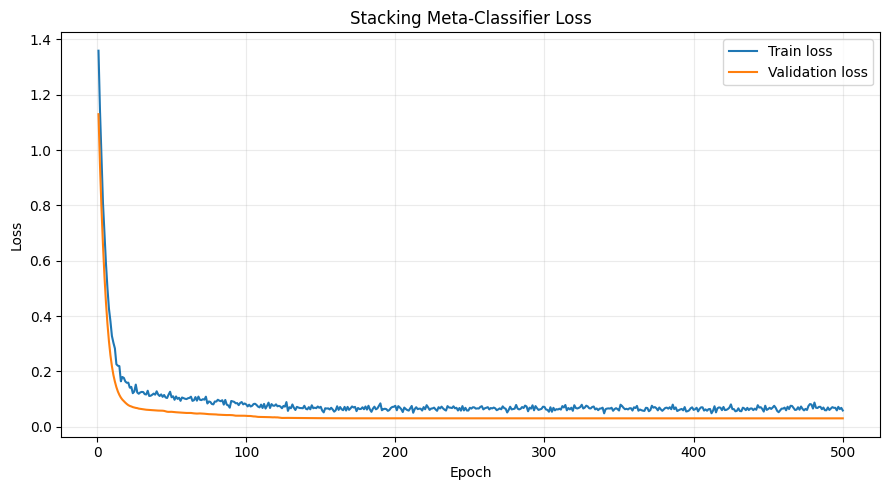

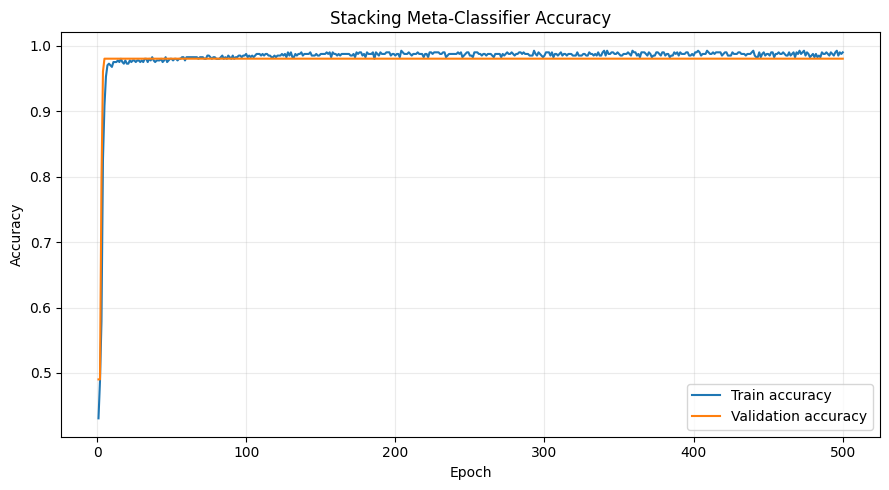

In [32]:

# ============================================================
# 14. Plot stacking training history
# ============================================================

history_df = pd.DataFrame(history.history)
display(history_df.tail())

history_df.to_csv(
    OUTPUT_DIR / "stacking_training_history.csv",
    index=False,
)

plt.figure(figsize=(9, 5))
plt.plot(history_df.index + 1, history_df["loss"], label="Train loss")
plt.plot(history_df.index + 1, history_df["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stacking Meta-Classifier Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df.index + 1, history_df["accuracy"], label="Train accuracy")
plt.plot(history_df.index + 1, history_df["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Stacking Meta-Classifier Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [33]:

# ============================================================
# 15. Load the BEST stacker and evaluate on untouched test data
# ============================================================

best_meta_model = keras.models.load_model(
    BEST_META_MODEL_PATH,
    compile=False,
)

test_stacking_prob = best_meta_model.predict(
    X_test_meta,
    batch_size=META_BATCH_SIZE,
    verbose=1,
)

test_stacking_pred = np.argmax(test_stacking_prob, axis=1)

print("Test probability shape:", test_stacking_prob.shape)
print("Test prediction shape :", test_stacking_pred.shape)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Test probability shape: (253, 4)
Test prediction shape : (253,)


In [34]:

# ============================================================
# 16. Overall test metrics
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    test_stacking_pred,
)

test_macro_f1 = f1_score(
    y_test,
    test_stacking_pred,
    labels=np.arange(NUM_CLASSES),
    average="macro",
    zero_division=0,
)

test_weighted_f1 = f1_score(
    y_test,
    test_stacking_pred,
    labels=np.arange(NUM_CLASSES),
    average="weighted",
    zero_division=0,
)

test_balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_stacking_pred,
)

summary_df = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "macro_f1",
            "weighted_f1",
            "balanced_accuracy",
        ],
        "value": [
            test_accuracy,
            test_macro_f1,
            test_weighted_f1,
            test_balanced_accuracy,
        ],
    }
)

print("STACKING ENSEMBLE — UNTOUCHED TEST SET")
display(summary_df.style.format({"value": "{:.6f}"}))

summary_df.to_csv(
    OUTPUT_DIR / "stacking_test_summary_metrics.csv",
    index=False,
)


STACKING ENSEMBLE — UNTOUCHED TEST SET


,metric,value
0,accuracy,0.996047
1,macro_f1,0.992942
2,weighted_f1,0.996084
3,balanced_accuracy,0.997525


In [35]:

# ============================================================
# 17. Per-class precision, recall, and F1
# ============================================================

precision, recall, per_class_f1, support = precision_recall_fscore_support(
    y_test,
    test_stacking_pred,
    labels=np.arange(NUM_CLASSES),
    average=None,
    zero_division=0,
)

per_class_df = pd.DataFrame(
    {
        "class": CLASS_NAMES,
        "precision": precision,
        "recall": recall,
        "f1": per_class_f1,
        "support": support,
    }
)

display(
    per_class_df.style.format(
        {
            "precision": "{:.6f}",
            "recall": "{:.6f}",
            "f1": "{:.6f}",
        }
    )
)

per_class_df.to_csv(
    OUTPUT_DIR / "stacking_test_per_class_metrics.csv",
    index=False,
)


,class,precision,recall,f1,support
0,molded,1.000000,1.000000,1.000000,38
1,normal,1.000000,0.990099,0.995025,101
2,rotten,0.954545,1.000000,0.976744,21
3,sprouted,1.000000,1.000000,1.000000,93


Confusion matrix counts:


,Pred_molded,Pred_normal,Pred_rotten,Pred_sprouted
True_molded,38,0,0,0
True_normal,0,100,1,0
True_rotten,0,0,21,0
True_sprouted,0,0,0,93


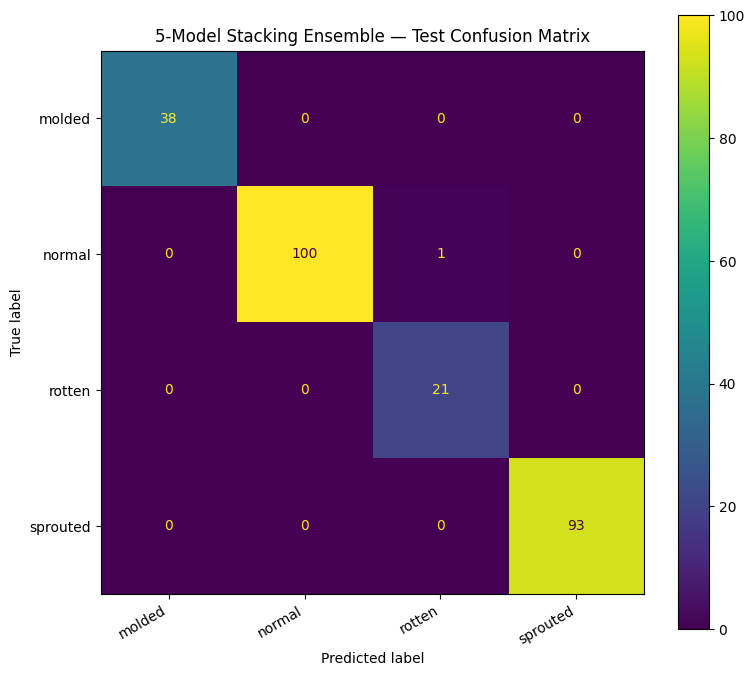

Saved: /kaggle/working/stacking_confusion_matrix.png


In [36]:

# ============================================================
# 18. Confusion matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    test_stacking_pred,
    labels=np.arange(NUM_CLASSES),
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{c}" for c in CLASS_NAMES],
    columns=[f"Pred_{c}" for c in CLASS_NAMES],
)

print("Confusion matrix counts:")
display(cm_df)

cm_df.to_csv(
    OUTPUT_DIR / "stacking_confusion_matrix.csv",
)

fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
)

disp.plot(
    ax=ax,
    values_format="d",
)

ax.set_title("5-Model Stacking Ensemble — Test Confusion Matrix")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

CONFUSION_MATRIX_PNG = OUTPUT_DIR / "stacking_confusion_matrix.png"
plt.savefig(
    CONFUSION_MATRIX_PNG,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", CONFUSION_MATRIX_PNG)


In [37]:

# ============================================================
# 19. Compare base models, soft voting, and stacking
# ============================================================

comparison_rows = []

for model_name, probs in test_probabilities.items():
    row = {"model": model_name}
    row.update(summary_metrics(y_test, probs))
    comparison_rows.append(row)

soft_row = {"model": "Equal-weight soft voting"}
soft_row.update(summary_metrics(y_test, soft_vote_test_prob))
comparison_rows.append(soft_row)

stack_row = {
    "model": "5-model stacking ensemble",
    "accuracy": test_accuracy,
    "macro_f1": test_macro_f1,
    "weighted_f1": test_weighted_f1,
    "balanced_accuracy": test_balanced_accuracy,
}
comparison_rows.append(stack_row)

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    "macro_f1",
    ascending=False,
).reset_index(drop=True)

display(
    comparison_df.style.format(
        {
            "accuracy": "{:.6f}",
            "macro_f1": "{:.6f}",
            "weighted_f1": "{:.6f}",
            "balanced_accuracy": "{:.6f}",
        }
    )
)

comparison_df.to_csv(
    OUTPUT_DIR / "all_models_and_ensemble_test_comparison.csv",
    index=False,
)


,model,accuracy,macro_f1,weighted_f1,balanced_accuracy
0,5-model stacking ensemble,0.996047,0.992942,0.996084,0.997525
1,DenseNet121,0.988142,0.987774,0.988174,0.992148
2,ConvNeXtTiny,0.992095,0.986041,0.992254,0.994837
3,Equal-weight soft voting,0.984190,0.976353,0.984190,0.976353
4,EfficientNetV2B0,0.980237,0.975806,0.980256,0.973665
5,ResNet50V2,0.976285,0.969139,0.976251,0.967086
6,Xception,0.964427,0.940069,0.964203,0.935262


In [38]:

# ============================================================
# 20. Save per-image test predictions
# ============================================================

prediction_df = pd.DataFrame(
    {
        "image_path": test_paths,
        "true_index": y_test,
        "true_class": [CLASS_NAMES[i] for i in y_test],
        "predicted_index": test_stacking_pred,
        "predicted_class": [CLASS_NAMES[i] for i in test_stacking_pred],
        "confidence": np.max(test_stacking_prob, axis=1),
    }
)

for i, class_name in enumerate(CLASS_NAMES):
    prediction_df[f"prob_{class_name}"] = test_stacking_prob[:, i]

prediction_df["correct"] = (
    prediction_df["true_index"] == prediction_df["predicted_index"]
)

display(prediction_df.head(20))

prediction_df.to_csv(
    OUTPUT_DIR / "stacking_test_predictions.csv",
    index=False,
)


,image_path,true_index,true_class,predicted_index,predicted_class,confidence,prob_molded,prob_normal,prob_rotten,prob_sprouted,correct
0,/kaggle/input/datasets/yashraneja2/onion-datas...,0,molded,0,molded,0.995338,0.995338,0.000225,0.003816,0.000621,True
1,/kaggle/input/datasets/yashraneja2/onion-datas...,0,molded,0,molded,0.995913,0.995913,0.000199,0.003371,0.000517,True
2,/kaggle/input/datasets/yashraneja2/onion-datas...,0,molded,0,molded,0.995064,0.995064,0.000235,0.004058,0.000643,True
3,/kaggle/input/datasets/yashraneja2/onion-datas...,0,molded,0,molded,0.995553,0.995553,0.000218,0.003636,0.000594,True
4,/kaggle/input/datasets/yashraneja2/onion-datas...,0,molded,0,molded,0.990257,0.990257,0.000562,0.007842,0.001340,True
5,/kaggle/input/datasets/yashraneja2/onion-datas...,0,molded,0,molded,0.991247,0.991247,0.000420,0.006822,0.001511,True
6,/kaggle/input/datasets/yashraneja2/onion-datas...,0,molded,0,molded,0.995010,0.995010,0.000258,0.004052,0.000679,True
7,/kaggle/input/datasets/yashraneja2/onion-datas...,0,molded,0,molded,0.650261,0.650261,0.049802,0.229824,0.070113,True
8,/kaggle/input/datasets/yashraneja2/onion-datas...,0,molded,0,molded,0.995668,0.995668,0.000208,0.003547,0.000576,True
9,/kaggle/input/datasets/yashraneja2/onion-datas...,0,molded,0,molded,0.995879,0.995879,0.000199,0.003407,0.000514,True


In [39]:

# ============================================================
# 21. Save ensemble metadata
# ============================================================

feature_names = []

for model_name in STACK_MODEL_ORDER:
    for class_name in CLASS_NAMES:
        feature_names.append(f"{model_name}__prob_{class_name}")

metadata = {
    "ensemble_type": "stacking",
    "base_models": STACK_MODEL_ORDER,
    "h5_load_modes": h5_load_modes,
    "base_model_paths": {
        name: str(resolved_model_paths[name])
        for name in STACK_MODEL_ORDER
    },
    "class_names": CLASS_NAMES,
    "num_classes": NUM_CLASSES,
    "feature_count": len(feature_names),
    "feature_order": feature_names,
    "base_input_sizes": {
        name: MODEL_SPECS[name]["image_size"]
        for name in STACK_MODEL_ORDER
    },
    "meta_train_source": "original validation split",
    "meta_validation_fraction": META_VALID_FRACTION,
    "random_seed": SEED,
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1),
    "test_balanced_accuracy": float(test_balanced_accuracy),
    "best_meta_model_path": str(BEST_META_MODEL_PATH),
    "final_meta_model_path": str(FINAL_META_MODEL_PATH),
}

METADATA_PATH = OUTPUT_DIR / "onion_stacking_metadata.json"

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(json.dumps(metadata, indent=2))


{
  "ensemble_type": "stacking",
  "base_models": [
    "ConvNeXtTiny",
    "EfficientNetV2B0",
    "DenseNet121",
    "ResNet50V2",
    "Xception"
  ],
  "h5_load_modes": {
    "ConvNeXtTiny": "reconstructed_plus_load_weights",
    "EfficientNetV2B0": "reconstructed_plus_load_weights",
    "DenseNet121": "reconstructed_plus_load_weights",
    "ResNet50V2": "reconstructed_plus_load_weights",
    "Xception": "reconstructed_plus_load_weights"
  },
  "base_model_paths": {
    "ConvNeXtTiny": "/kaggle/input/datasets/yashraneja/models-onion/Model Files/convnexttiny_model.weights.h5",
    "EfficientNetV2B0": "/kaggle/input/datasets/yashraneja/models-onion/Model Files/effnetv2b0model.weights.h5",
    "DenseNet121": "/kaggle/input/datasets/yashraneja/models-onion/Model Files/onion_densenet121_best_macro_f1.weights.h5",
    "ResNet50V2": "/kaggle/input/datasets/yashraneja/models-onion/Model Files/resnet_model.weights.h5",
    "Xception": "/kaggle/input/datasets/yashraneja/models-onion/Model Fil

In [40]:

# ============================================================
# 22. Final output-file list
# ============================================================

important_outputs = [
    BEST_META_MODEL_PATH,
    FINAL_META_MODEL_PATH,
    OUTPUT_DIR / "onion_base_model_predictions.npz",
    OUTPUT_DIR / "stacking_training_history.csv",
    OUTPUT_DIR / "stacking_test_summary_metrics.csv",
    OUTPUT_DIR / "stacking_test_per_class_metrics.csv",
    OUTPUT_DIR / "stacking_confusion_matrix.csv",
    OUTPUT_DIR / "stacking_confusion_matrix.png",
    OUTPUT_DIR / "stacking_test_predictions.csv",
    OUTPUT_DIR / "all_models_and_ensemble_test_comparison.csv",
    OUTPUT_DIR / "base_model_test_summary.csv",
    METADATA_PATH,
]

print("Files created in /kaggle/working:\n")

for path in important_outputs:
    if Path(path).exists():
        print("✓", path)
    else:
        print("MISSING:", path)

print(
    "\nThe main trained stacking component is:\n"
    f"  {BEST_META_MODEL_PATH}\n\n"
    "Keep it together with the same five base .keras models because "
    "the stacker consumes their 20 probability outputs."
)


Files created in /kaggle/working:

✓ /kaggle/working/onion_stacking_meta_classifier_best.keras
✓ /kaggle/working/onion_stacking_meta_classifier_final.keras
✓ /kaggle/working/onion_base_model_predictions.npz
✓ /kaggle/working/stacking_training_history.csv
✓ /kaggle/working/stacking_test_summary_metrics.csv
✓ /kaggle/working/stacking_test_per_class_metrics.csv
✓ /kaggle/working/stacking_confusion_matrix.csv
✓ /kaggle/working/stacking_confusion_matrix.png
✓ /kaggle/working/stacking_test_predictions.csv
✓ /kaggle/working/all_models_and_ensemble_test_comparison.csv
✓ /kaggle/working/base_model_test_summary.csv
✓ /kaggle/working/onion_stacking_metadata.json

The main trained stacking component is:
  /kaggle/working/onion_stacking_meta_classifier_best.keras

Keep it together with the same five base .keras models because the stacker consumes their 20 probability outputs.



## Important

The saved stacking model is only the **meta-classifier**. For deployment, keep it together with the five H5 base-model files because the stacker expects their 20 probability outputs.

If the notebook prints `reconstructed_plus_load_weights`, that confirms the corresponding `.h5` file was weights-only and the architecture was reconstructed before loading the weights.


In [41]:
# ============================================================
# Export trained Keras stacking meta-classifier to PyTorch .pth
# ============================================================

import torch
import torch.nn as nn
import numpy as np
from tensorflow import keras
from pathlib import Path
from IPython.display import FileLink, display

# ------------------------------------------------------------
# 1. Load best trained Keras stacking classifier
# ------------------------------------------------------------

KERAS_META_PATH = Path(
    "/kaggle/working/onion_stacking_meta_classifier_best.keras"
)

keras_meta = keras.models.load_model(
    KERAS_META_PATH,
    compile=False
)

print("Loaded:", KERAS_META_PATH)


# ------------------------------------------------------------
# 2. Build equivalent PyTorch stacking classifier
# ------------------------------------------------------------

class OnionStackingMetaClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.meta_dense = nn.Linear(
            20,     # 5 models × 4 classes
            32
        )

        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(
            p=0.20
        )

        self.output = nn.Linear(
            32,
            4
        )

    def forward(self, x):

        x = self.meta_dense(x)

        x = self.relu(x)

        x = self.dropout(x)

        x = self.output(x)

        # Return probabilities
        return torch.softmax(x, dim=1)


torch_model = OnionStackingMetaClassifier()


# ------------------------------------------------------------
# 3. Copy weights from Keras -> PyTorch
# ------------------------------------------------------------

# First Dense layer
keras_dense1 = keras_meta.get_layer("meta_dense")

W1, b1 = keras_dense1.get_weights()

with torch.no_grad():

    torch_model.meta_dense.weight.copy_(
        torch.tensor(
            W1.T,
            dtype=torch.float32
        )
    )

    torch_model.meta_dense.bias.copy_(
        torch.tensor(
            b1,
            dtype=torch.float32
        )
    )


# Final classification layer
keras_output = keras_meta.get_layer(
    "stacked_prediction"
)

W2, b2 = keras_output.get_weights()

with torch.no_grad():

    torch_model.output.weight.copy_(
        torch.tensor(
            W2.T,
            dtype=torch.float32
        )
    )

    torch_model.output.bias.copy_(
        torch.tensor(
            b2,
            dtype=torch.float32
        )
    )


torch_model.eval()

print("Weights transferred successfully.")


# ------------------------------------------------------------
# 4. Save .pth
# ------------------------------------------------------------

PTH_PATH = Path(
    "/kaggle/working/onion_5model_stacking_ensemble.pth"
)

CLASS_NAMES = [
    "molded",
    "normal",
    "rotten",
    "sprouted"
]

BASE_MODELS = [
    "ConvNeXtTiny",
    "EfficientNetV2B0",
    "DenseNet121",
    "ResNet50V2",
    "Xception"
]

torch.save(
    {
        "model_state_dict": torch_model.state_dict(),

        "class_names": CLASS_NAMES,

        "base_models": BASE_MODELS,

        "input_features": 20,

        "num_classes": 4,

        "architecture": {
            "input": 20,
            "hidden": 32,
            "dropout": 0.20,
            "output": 4
        }
    },

    PTH_PATH
)


print("\nPTH CREATED SUCCESSFULLY")
print(PTH_PATH)
print(
    "Size:",
    round(PTH_PATH.stat().st_size / 1024, 2),
    "KB"
)


# ------------------------------------------------------------
# 5. Create clickable download link
# ------------------------------------------------------------

display(
    FileLink(
        str(PTH_PATH)
    )
)

Loaded: /kaggle/working/onion_stacking_meta_classifier_best.keras
Weights transferred successfully.

PTH CREATED SUCCESSFULLY
/kaggle/working/onion_5model_stacking_ensemble.pth
Size: 6.25 KB


/kaggle/working/onion_5model_stacking_ensemble.pth